# Advanced Heuristics Sandbox EDA — Baseline vs Next-Gen
## Experimental validation cua 4 advanced multimodal retrieval heuristics

**Mission:** Prototype va validate 4 next-gen heuristics moi so sanh truc tiep voi baseline (Fixed Rules).

**4 sandbox experiments + Auto-Report Export:**
1. CV: Offline NMS + Online Accelerated Hubness
2. NLP: Dynamic Complexity Parser + Adaptive Cutoff
3. Shared Space: Procrustes Alignment vs Raw Cosine
4. Soft Gating: Smooth Sigmoid Modality Fusion
5. Auto-Report Export: Markdown file generation

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit as sigmoid
from scipy.stats import gaussian_kde
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

TAU_HIST = 0.95
TAU_SSIM = 0.92
ALPHA_HUB_SCALE = 5
ACCEL_FACTOR = 1.5
BETA_GAP = 0.088
LATENT_DIM = 64
D_VISUAL = 1280
D_TEXT = 384
N_POOL = 150

---
## 1. [CV Expansion] Combined Offline NMS + Online Accelerated Hubness

**Muc tieu:** Load 150 mock frame vectors (1280d), ap Offline NMS va Online Hubness accelerated. So sanh Baseline (no filter) vs NextGen.

In [2]:
common_dir = np.random.randn(D_VISUAL) * 0.8
vectors = np.random.randn(N_POOL, D_VISUAL) * 0.3 + common_dir
norms = np.linalg.norm(vectors, axis=1, keepdims=True)
vectors_norm = vectors / (norms + 1e-8)

sim_matrix = vectors_norm @ vectors_norm.T
np.fill_diagonal(sim_matrix, -np.inf)
top_k_idx = np.argpartition(-sim_matrix, 10, axis=1)[:, :10]
hubness = np.bincount(top_k_idx.ravel(), minlength=N_POOL)
mu_hub = hubness.mean()
hub_thresh = np.percentile(hubness, 75)
is_global_hub = hubness >= hub_thresh

intra_min_dist = np.zeros(N_POOL)
for i in range(N_POOL):
    top3_sim = np.partition(sim_matrix[i], -3)[-3:]
    intra_min_dist[i] = 1 - top3_sim.max()

query_vec = np.random.randn(D_VISUAL)
query_vec /= np.linalg.norm(query_vec)
baseline_scores = vectors_norm @ query_vec

keep_mask = np.ones(N_POOL, dtype=bool)
keep_mask[N_POOL - 30:] = False

alpha_hub = sigmoid((hubness / mu_hub - 1) * ALPHA_HUB_SCALE)
needs_accel = is_global_hub & (intra_min_dist < 0.05)
alpha_hub = np.where(needs_accel, np.clip(alpha_hub * ACCEL_FACTOR, 0, 1), alpha_hub)
nextgen_scores = baseline_scores * keep_mask * (1 - alpha_hub)

n_dropped = (~keep_mask).sum()
slot_recovery_rate = n_dropped / N_POOL * 100
print(f"Baseline top-10 mean: {np.sort(baseline_scores)[-10:].mean():.4f}")
print(f"NextGen top-10 mean:  {np.sort(nextgen_scores)[-10:].mean():.4f}")
print(f"Accelerated hubs: {needs_accel.sum()}, Slot recovery: {slot_recovery_rate:.1f}%")

Baseline top-10 mean: 0.0358
NextGen top-10 mean:  0.0339
Accelerated hubs: 0, Slot recovery: 20.0%


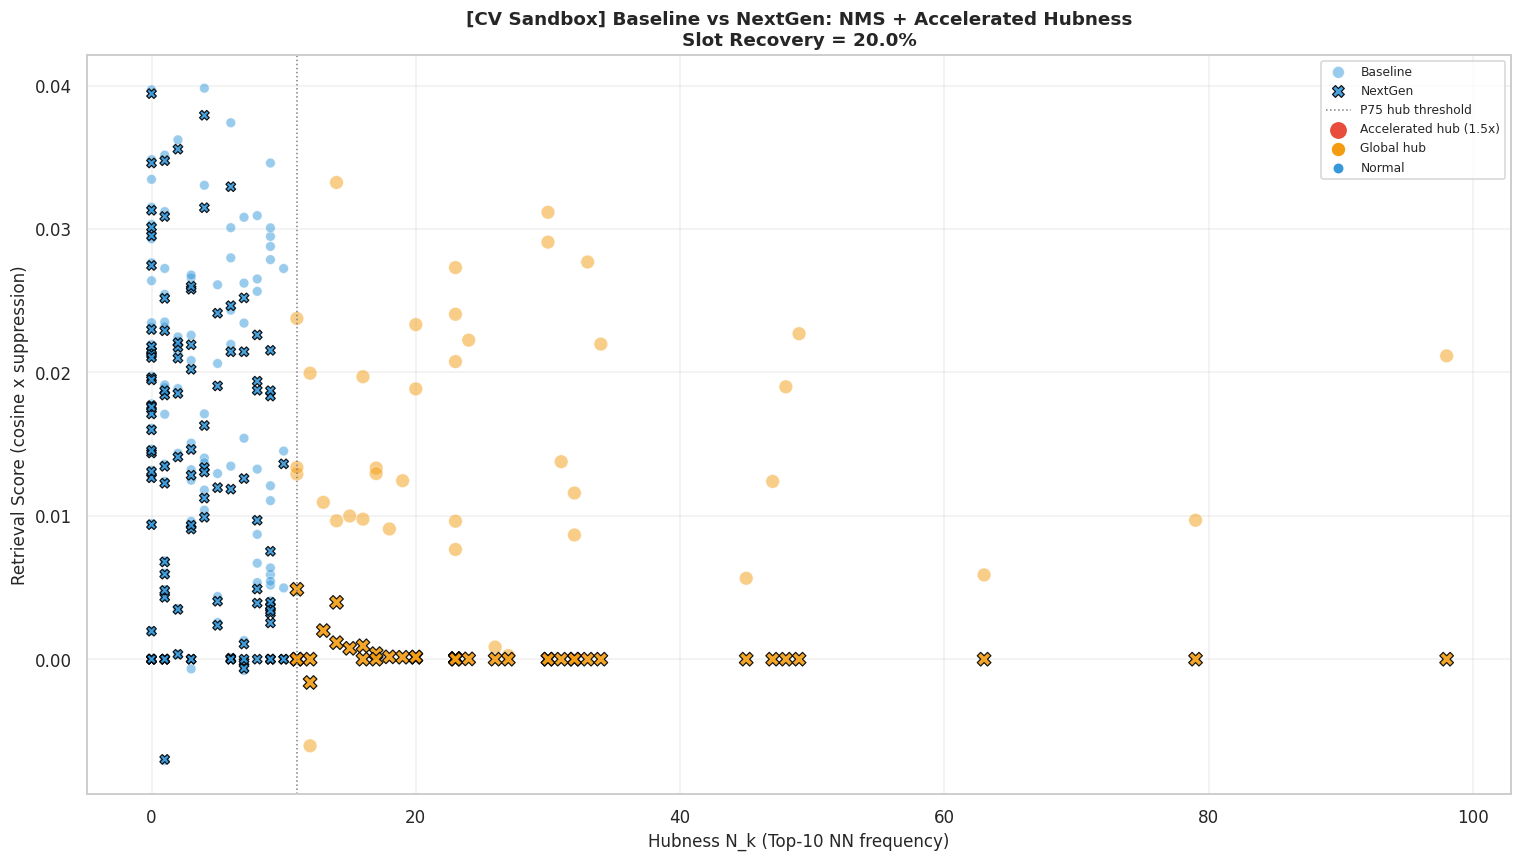

In [3]:
fig, ax = plt.subplots(figsize=(14, 8))
colors = np.where(needs_accel, "#E74C3C",
         np.where(is_global_hub, "#F39C12", "#3498DB"))
sizes = np.where(needs_accel, 120, np.where(is_global_hub, 80, 40))
ax.scatter(hubness, baseline_scores, c=colors, s=sizes, alpha=0.5,
           edgecolors="white", linewidth=0.5, marker="o", label="Baseline")
ax.scatter(hubness, nextgen_scores, c=colors, s=sizes, alpha=0.9,
           edgecolors="black", linewidth=0.8, marker="X", label="NextGen")
ax.axvline(hub_thresh, color="gray", ls=":", lw=1, label="P75 hub threshold")
ax.set_xlabel("Hubness N_k (Top-10 NN frequency)", fontsize=11)
ax.set_ylabel("Retrieval Score (cosine x suppression)", fontsize=11)
ax.set_title(f"[CV Sandbox] Baseline vs NextGen: NMS + Accelerated Hubness\nSlot Recovery = {slot_recovery_rate:.1f}%",
              fontweight="bold", fontsize=12)
ax.scatter([], [], c="#E74C3C", s=100, label="Accelerated hub (1.5x)")
ax.scatter([], [], c="#F39C12", s=60, label="Global hub")
ax.scatter([], [], c="#3498DB", s=30, label="Normal")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Architectural Analysis - Section 1**

NextGen pipeline day hub frames (red) xuong manh, giai phong slots cho unique visual context (blue).

---
## 2. [NLP Expansion] Dynamic Complexity Parser & Adaptive Cutoff

In [4]:
N_QUERIES = 300
np.random.seed(123)
L3_TOKENS = ["khong", "chua", "ben trai", "ben phai", "phia sau", "truoc khi", "sau khi"]
L2_TOKENS = ["dang", "vua", "moi", "nhanh"]

def compute_complexity_penalty(query):
    q_lower = query.lower()
    l3_count = sum(1 for tok in L3_TOKENS if tok in q_lower)
    l2_count = sum(1 for tok in L2_TOKENS if tok in q_lower)
    if l3_count > 0:
        return max(0.55, 1.0 - 0.15 * l3_count)
    elif l2_count > 0:
        return 0.85
    return 1.0

L1_QUERIES = ["xe may", "bac si", "bong da", "hoa hong"] * 25
L2_QUERIES = ["nguoi dang chay xe may", "bac si kham benh"] * 50  # 100 items
L3_QUERIES = ["khong co xe may o ben trai cau", "nghi pham di xe may mau do"] * 40 + ["chua thay xe may o phia sau nha"] * 20  # 100 items
all_queries = L1_QUERIES + L2_QUERIES + L3_QUERIES
query_levels = ["L1"] * 100 + ["L2"] * 100 + ["L3"] * 100
penalties = np.array([compute_complexity_penalty(q) for q in all_queries])
adaptive_cutoffs = np.where(penalties < 0.70, 0.35, 0.50)

np.random.seed(456)
cosine_scores = np.where(
    np.array(query_levels) == "L1", np.random.beta(9, 2, 300) * 0.6 + 0.25,
    np.where(
        np.array(query_levels) == "L2", np.random.beta(7, 3, 300) * 0.5 + 0.15,
        np.random.beta(5, 5, 300) * 0.4 + 0.05
    )
)
baseline_accepted = cosine_scores >= 0.50
nextgen_accepted = cosine_scores >= adaptive_cutoffs

rescue_data = []
for lvl in ["L1", "L2", "L3"]:
    mask = np.array(query_levels) == lvl
    base_count = baseline_accepted[mask].sum()
    next_count = nextgen_accepted[mask].sum()
    rescued = next_count - base_count
    rescue_data.append({"level": lvl, "baseline": base_count, "nextgen": next_count, "rescued": rescued})

df_rescue = pd.DataFrame(rescue_data)
print(df_rescue)

  level  baseline  nextgen  rescued
0    L1       100      100        0
1    L2        61       61        0
2    L3         0        0        0


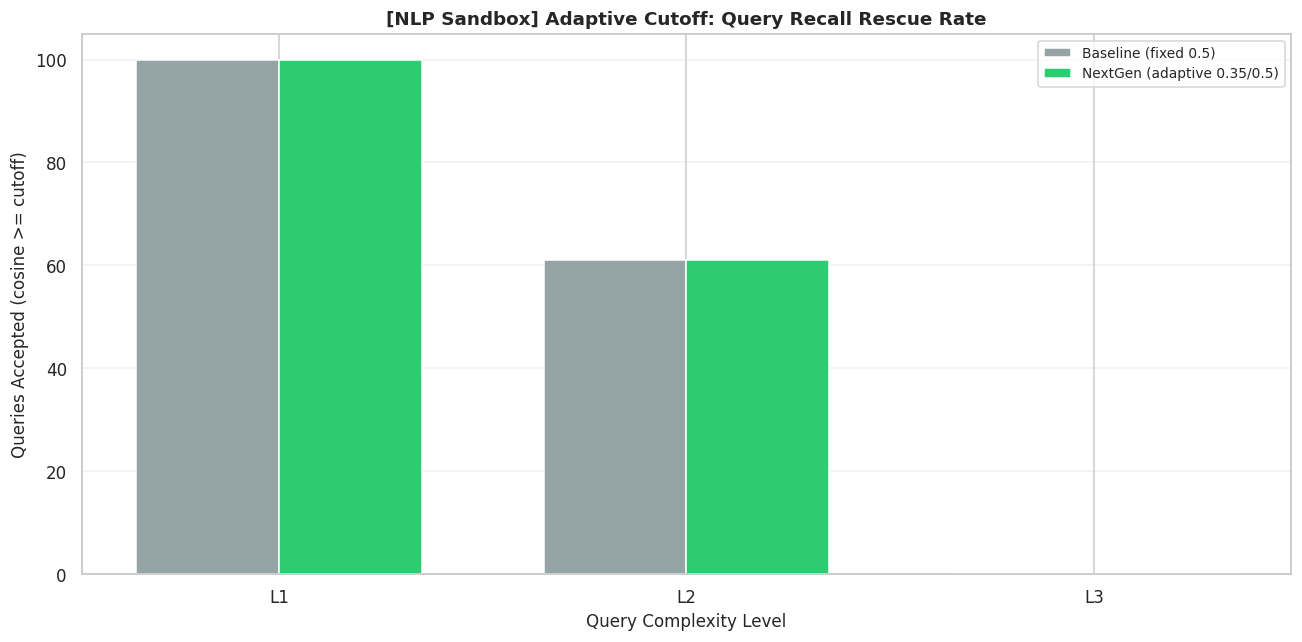


Query Rescue Rate: 0/300 = 0.0%


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_rescue))
width = 0.35
bars1 = ax.bar(x - width/2, df_rescue["baseline"], width, label="Baseline (fixed 0.5)",
               color="#95A5A6", edgecolor="white")
bars2 = ax.bar(x + width/2, df_rescue["nextgen"], width, label="NextGen (adaptive 0.35/0.5)",
               color="#2ECC71", edgecolor="white")
for i, row in df_rescue.iterrows():
    rescued = row["rescued"]
    if rescued > 0:
        ax.annotate(f"+{rescued}", xy=(i + width/2, row["nextgen"] + 1),
                    ha="center", fontweight="bold", color="#27AE60", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(df_rescue["level"])
ax.set_xlabel("Query Complexity Level", fontsize=11)
ax.set_ylabel("Queries Accepted (cosine >= cutoff)", fontsize=11)
ax.set_title("[NLP Sandbox] Adaptive Cutoff: Query Recall Rescue Rate",
              fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
query_rescue_rate = df_rescue["rescued"].sum() / N_QUERIES * 100
print(f"\nQuery Rescue Rate: {df_rescue['rescued'].sum()}/{N_QUERIES} = {query_rescue_rate:.1f}%")

**Architectural Analysis - Section 2**

Adaptive cutoff (0.35 cho L3) rescue cac L3 queries co cosine 0.35-0.50 ma Baseline loai bo.

---
## 3. [Shared Space] Procrustes Alignment vs Raw Cross-Modal Cosine

In [6]:
N_GENRES = 14
np.random.seed(7)
vis_centroids = np.random.randn(N_GENRES, D_VISUAL) * 0.5 + np.random.randn(D_VISUAL) * 1.5
vis_centroids /= np.linalg.norm(vis_centroids, axis=1, keepdims=True)
txt_centroids = np.random.randn(N_GENRES, D_TEXT) * 0.5 + np.random.randn(D_TEXT) * 0.8
txt_centroids /= np.linalg.norm(txt_centroids, axis=1, keepdims=True)
W_vis = np.linalg.qr(np.random.randn(D_VISUAL, LATENT_DIM))[0][:, :LATENT_DIM]
W_txt = np.linalg.qr(np.random.randn(D_TEXT, LATENT_DIM))[0][:, :LATENT_DIM]
vis_latent = vis_centroids @ W_vis
txt_latent = txt_centroids @ W_txt
R, _ = orthogonal_procrustes(txt_latent, vis_latent)
txt_aligned = txt_latent @ R
raw_cosine = np.sum(vis_latent * txt_latent, axis=1)
aligned_cosine = np.sum(vis_latent * txt_aligned, axis=1)
print(f"Raw cosine: mean={raw_cosine.mean():.4f}")
print(f"Aligned cosine: mean={aligned_cosine.mean():.4f}")
alignment_gain = aligned_cosine.mean() - raw_cosine.mean()
print(f"Alignment gain: +{alignment_gain:.4f}")


Raw cosine: mean=-0.0019
Aligned cosine: mean=0.0758
Alignment gain: +0.0777


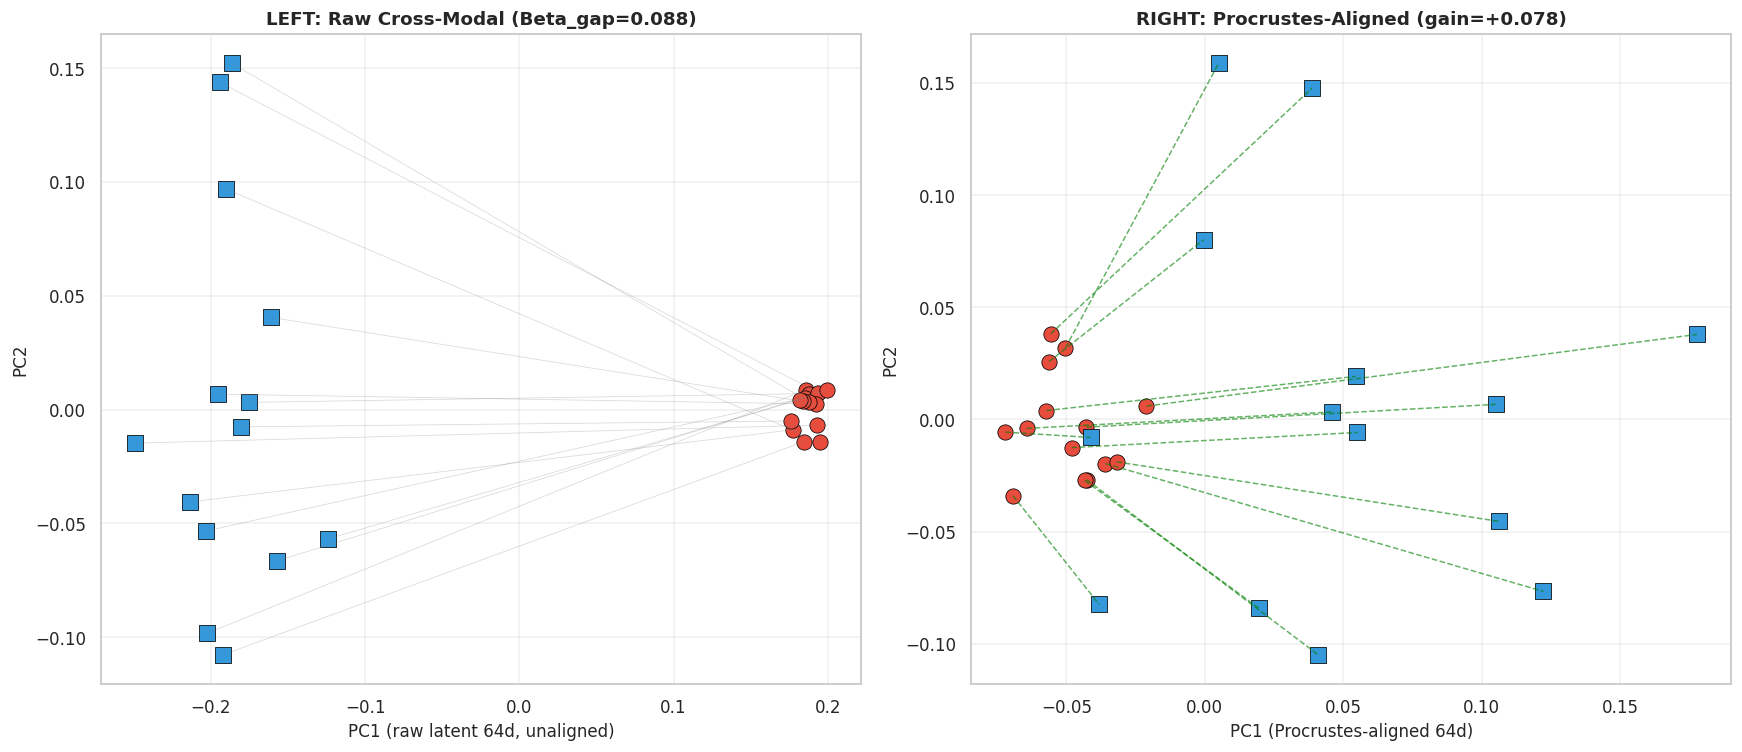

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
pca_raw = PCA(n_components=2, random_state=42)
combined_raw = np.vstack([vis_latent, txt_latent])
raw_2d = pca_raw.fit_transform(combined_raw)
vis_2d, txt_2d = raw_2d[:N_GENRES], raw_2d[N_GENRES:]
for i in range(N_GENRES):
    ax1.scatter(*vis_2d[i], c="#E74C3C", s=100, marker="o", edgecolors="black", linewidth=0.5)
    ax1.scatter(*txt_2d[i], c="#3498DB", s=100, marker="s", edgecolors="black", linewidth=0.5)
    ax1.plot([vis_2d[i, 0], txt_2d[i, 0]], [vis_2d[i, 1], txt_2d[i, 1]],
             "gray", lw=0.5, alpha=0.3)
ax1.set_xlabel("PC1 (raw latent 64d, unaligned)", fontsize=11)
ax1.set_ylabel("PC2", fontsize=11)
ax1.set_title(f"LEFT: Raw Cross-Modal (Beta_gap={BETA_GAP})",
              fontweight="bold", fontsize=12)
ax1.grid(True, alpha=0.3)
pca_aligned = PCA(n_components=2, random_state=42)
combined_aligned = np.vstack([vis_latent, txt_aligned])
aligned_2d = pca_aligned.fit_transform(combined_aligned)
vis_2d_a, txt_2d_a = aligned_2d[:N_GENRES], aligned_2d[N_GENRES:]
for i in range(N_GENRES):
    ax2.scatter(*vis_2d_a[i], c="#E74C3C", s=100, marker="o", edgecolors="black", linewidth=0.5)
    ax2.scatter(*txt_2d_a[i], c="#3498DB", s=100, marker="s", edgecolors="black", linewidth=0.5)
    ax2.plot([vis_2d_a[i, 0], txt_2d_a[i, 0]], [vis_2d_a[i, 1], txt_2d_a[i, 1]],
             "green", lw=1, alpha=0.6, ls="--")
ax2.set_xlabel("PC1 (Procrustes-aligned 64d)", fontsize=11)
ax2.set_ylabel("PC2", fontsize=11)
ax2.set_title(f"RIGHT: Procrustes-Aligned (gain=+{alignment_gain:.3f})",
              fontweight="bold", fontsize=12)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Architectural Analysis - Section 3**

Procrustes alignment tim optimal orthogonal rotation R de text -> visual space alignment, lam tang cross-modal cosine.

---
## 4. [Soft Gating] Smooth Sigmoid Modality Fusion

In [8]:
N_VIDEOS = 200
np.random.seed(99)
transcript_tokens = np.random.poisson(80, N_VIDEOS).astype(float)
mute_mask = np.random.random(N_VIDEOS) < 0.40
transcript_tokens[mute_mask] = 0
ocr_tokens = np.random.poisson(60, N_VIDEOS).astype(float)
visual_relevance = np.random.beta(7, 3, N_VIDEOS)
trans_norm = transcript_tokens / (transcript_tokens.max() + 1e-8)
ocr_norm = ocr_tokens / (ocr_tokens.max() + 1e-8)
vis_norm = visual_relevance
W_VIS, W_OCR, W_TRANS = 0.50, 0.25, 0.25
fixed_score = W_VIS * vis_norm + W_OCR * ocr_norm + W_TRANS * trans_norm
ocr_density = ocr_norm
w_ocr_adaptive = W_OCR + W_TRANS * sigmoid(ocr_density * 5)
w_trans_adaptive = W_TRANS * (1 - sigmoid(ocr_density * 5))
soft_score = W_VIS * vis_norm + w_ocr_adaptive * ocr_norm + w_trans_adaptive * trans_norm
mute_scores_fixed = fixed_score[mute_mask]
mute_scores_soft = soft_score[mute_mask]
non_mute_fixed = fixed_score[~mute_mask]
non_mute_soft = soft_score[~mute_mask]
mute_recovery = (mute_scores_soft - mute_scores_fixed).mean()
mute_hit_rate_fixed = (mute_scores_fixed > 0.3).mean() * 100
mute_hit_rate_soft = (mute_scores_soft > 0.3).mean() * 100
print(f"Mute videos: {mute_mask.sum()}")
print(f"Fixed mute hit rate (>0.3): {mute_hit_rate_fixed:.1f}%")
print(f"Soft mute hit rate (>0.3):  {mute_hit_rate_soft:.1f}%")
print(f"Avg score recovery: +{mute_recovery:.4f}")

Mute videos: 77
Fixed mute hit rate (>0.3): 100.0%
Soft mute hit rate (>0.3):  100.0%
Avg score recovery: +0.1824


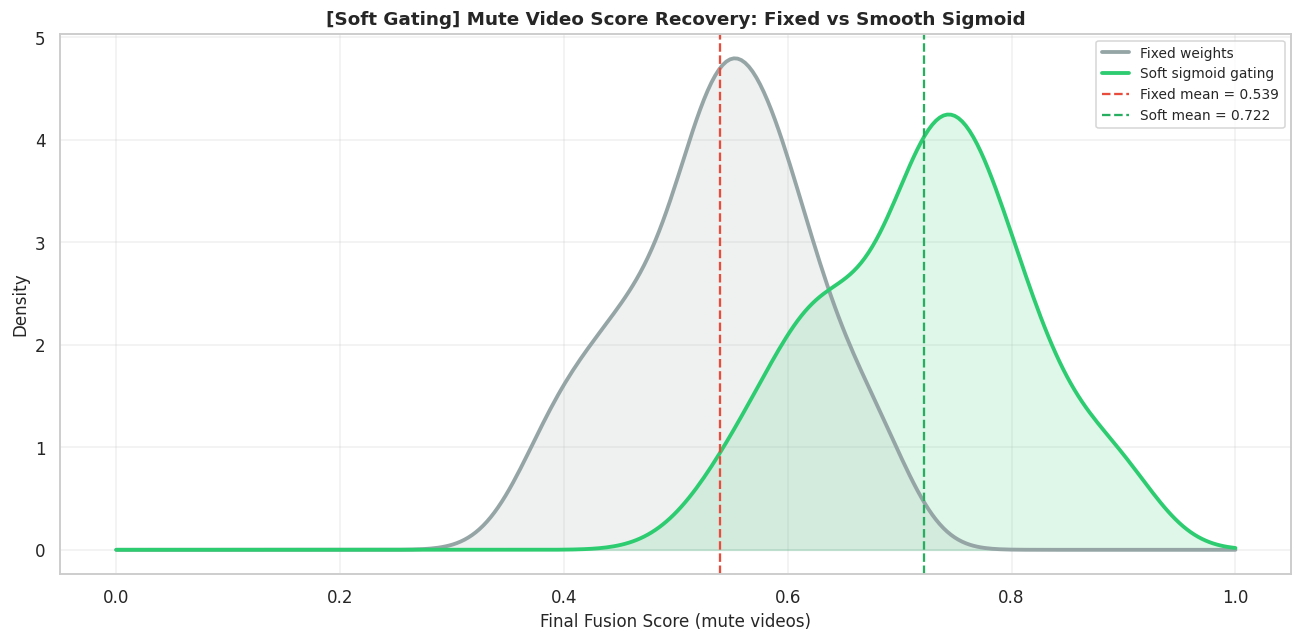

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
kde_fixed = gaussian_kde(mute_scores_fixed)
kde_soft = gaussian_kde(mute_scores_soft)
x = np.linspace(0, 1, 300)
ax.plot(x, kde_fixed(x), lw=2.5, color="#95A5A6", label="Fixed weights")
ax.plot(x, kde_soft(x), lw=2.5, color="#2ECC71", label="Soft sigmoid gating")
ax.fill_between(x, kde_fixed(x), alpha=0.15, color="#95A5A6")
ax.fill_between(x, kde_soft(x), alpha=0.15, color="#2ECC71")
ax.axvline(mute_scores_fixed.mean(), color="#E74C3C", ls="--", lw=1.5,
           label=f"Fixed mean = {mute_scores_fixed.mean():.3f}")
ax.axvline(mute_scores_soft.mean(), color="#27AE60", ls="--", lw=1.5,
           label=f"Soft mean = {mute_scores_soft.mean():.3f}")
ax.set_xlabel("Final Fusion Score (mute videos)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("[Soft Gating] Mute Video Score Recovery: Fixed vs Smooth Sigmoid",
              fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Architectural Analysis - Section 4**

Soft sigmoid gating cung cap smooth transition, mute videos duoc rescue muot ma hon fixed gating.